# Google Merch Store — EDA

**Goal:** Unsupervised segmentation of user behavior from event-log data. We want to discover distinct behavioral personas among users of an e-commerce store.

**Unit of analysis:** User (not event, not session). Raw data is event-level; we will aggregate to users after understanding the event structure.

**Dataset:** event logs from January 2021.

In [74]:
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.patches import Patch
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('data/ecom_shop.csv.gz', compression='gzip', parse_dates=['timestamp'])
df.head()

,timestamp,user_id,event,category,country,source,is_old_user,session_id,session_number,page_location,page_location_cats,event_order
0,2021-01-20 11:04:59.887247,1.000300e+06,session_start,desktop,India,(direct),False,1000299.7413851356_1,1,https://www.googlemerchandisestore.com/,main,0
1,2021-01-20 11:04:59.887247,1.000300e+06,main,desktop,India,(direct),False,1000299.7413851356_1,1,https://www.googlemerchandisestore.com/,main,1
2,2021-01-20 11:05:05.002377,1.000300e+06,main,desktop,India,(direct),False,1000299.7413851356_1,1,https://www.googlemerchandisestore.com/,main,1
3,2021-01-07 12:15:33.038847,1.000557e+06,session_start,mobile,India,<Other>,False,1000557.2911835024_1,1,https://shop.googlemerchandisestore.com/,main,0
4,2021-01-07 12:15:33.038847,1.000557e+06,main,mobile,India,<Other>,False,1000557.2911835024_1,1,https://shop.googlemerchandisestore.com/,main,1


### 1. Data Integrity

Check for structural problems before any analysis. Duplicates, co-logged events, and column redundancy can corrupt all downstream statistics.

In [75]:
# ── Exact duplicates ──
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes:,}  ({exact_dupes / len(df) * 100:.2f}%)")
if exact_dupes > 0:
    display(df[df.duplicated(keep=False)].sort_values(['session_id', 'timestamp']).head(10))

# ── Co-logged events (same session + timestamp, different event) ──
ts_counts = df.groupby(['session_id', 'timestamp']).size()
co_logged = ts_counts[ts_counts > 1]
print(f"\nCo-logged (session, timestamp) pairs: {len(co_logged):,}  ({co_logged.sum():,} rows, {co_logged.sum()/len(df)*100:.1f}%)")
print(f"Max events at single timestamp: {ts_counts.max()}")

combo_counts = (
    df.merge(co_logged.reset_index(name='n')[['session_id', 'timestamp']], on=['session_id', 'timestamp'])
    .groupby(['session_id', 'timestamp'])['event']
    .apply(lambda x: ' + '.join(sorted(x)))
    .value_counts()
)
print("\nMost common co-logged combos:")
combo_counts.head(10)

Exact duplicate rows: 0  (0.00%)

Co-logged (session, timestamp) pairs: 114,108  (228,225 rows, 41.6%)
Max events at single timestamp: 3

Most common co-logged combos:


event
main + session_start                 46551
product_list_view + session_start    35342
product_view + session_start         17044
search + view_search_results          7511
session_start + store_page            5327
basket + session_start                 998
session_start + sign_in                792
search + session_start                 283
add_to_cart + product_list_view        162
add_to_cart + product_view              24
Name: count, dtype: int64

In [76]:
# ── Near-duplicates (same row, dt < 3 seconds) ──
match_cols = ['user_id', 'event', 'category', 'country', 'source',
              'is_old_user', 'session_id', 'session_number',
              'page_location', 'page_location_cats', 'event_order']

df_s = df.sort_values(['session_id', 'timestamp']).reset_index(drop=True)
shifted     = df_s.groupby('session_id')[match_cols].shift(1)
ts_diff_sec = df_s.groupby('session_id')['timestamp'].diff().dt.total_seconds()

near_dup_mask = (df_s[match_cols] == shifted).all(axis=1) & (ts_diff_sec > 0) & (ts_diff_sec < 3)
near_dupes = df_s[near_dup_mask]

print(f"Near-duplicate rows: {len(near_dupes):,}  ({len(near_dupes)/len(df)*100:.2f}%)")
print(f"Sessions affected: {near_dupes['session_id'].nunique():,} | Users affected: {near_dupes['user_id'].nunique():,}")
print(f"\ndt distribution (sec): {near_dupes.assign(dt=ts_diff_sec[near_dup_mask])['dt'].describe().round(3).to_string()}")
print(f"\nMost duplicated events:")
display(near_dupes['event'].value_counts().head(10))

Near-duplicate rows: 16,596  (3.02%)
Sessions affected: 15,455 | Users affected: 14,896

dt distribution (sec): count    16596.000
mean         1.563
std          0.917
min          0.000
25%          0.825
50%          1.675
75%          2.342
max          3.000

Most duplicated events:


event
main                 5630
product_list_view    4923
product_view         4643
store_page            633
basket                275
sign_in               155
store_item_page       113
add_to_cart           106
search                 68
account_page           17
Name: count, dtype: int64

In [77]:
# ── Column redundancy ──

# event_order derivable from event?
eo_nuniq = df.groupby('event')['event_order'].nunique()
print(f"Events with unique event_order: {(eo_nuniq == 1).sum()}/{len(eo_nuniq)} -> {'1-to-1 mapping' if (eo_nuniq == 1).all() else 'NOT 1-to-1'}")

# page_location_cats derivable from page_location?
plc_nuniq = df.groupby('page_location')['page_location_cats'].nunique()
print(f"page_location -> page_location_cats: {'1-to-1' if (plc_nuniq == 1).all() else f'{(plc_nuniq > 1).sum()} ambiguous URLs'}")

# ── User-level consistency ──
incon_flag = (df.groupby('user_id')['is_old_user'].nunique() > 1).sum()
multi_country = (df.groupby('user_id')['country'].nunique() > 1).sum()
mixed_device = (df.groupby('session_id')['category'].nunique() > 1).sum()

print(f"\nis_old_user inconsistent across user's rows: {incon_flag:,}")
print(f"Users in >1 country: {multi_country:,}")
print(f"Sessions with >1 device: {mixed_device:,}")

Events with unique event_order: 22/22 -> 1-to-1 mapping
page_location -> page_location_cats: 1-to-1

is_old_user inconsistent across user's rows: 0
Users in >1 country: 0
Sessions with >1 device: 3


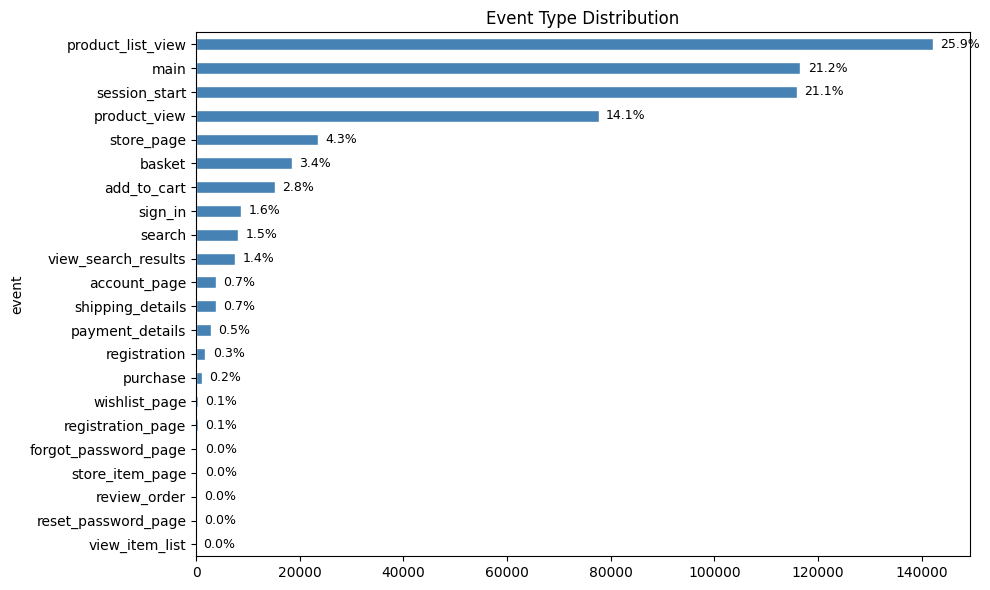

In [78]:
# ── Event type distribution ──
event_counts = df['event'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
event_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Event Type Distribution')
ax.invert_yaxis()
x_offset = max(event_counts) * 0.01
for bar in ax.patches:
    width = bar.get_width()
    pct = width / len(df) * 100
    ax.text(width + x_offset, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', ha='left', fontsize=9)
plt.tight_layout()
plt.show()

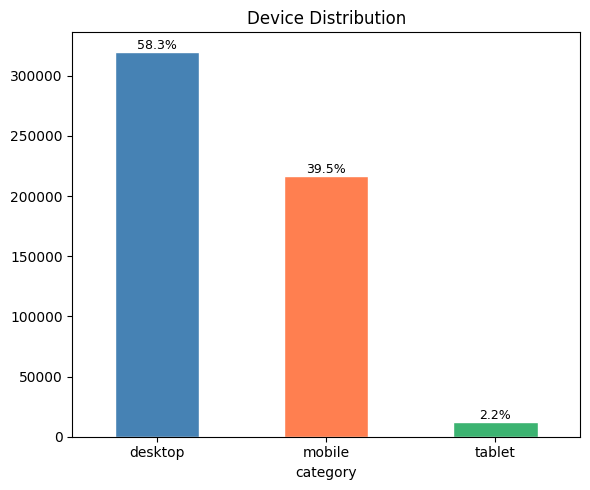

In [79]:
# ── Device distribution ──
device_counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
device_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white')
ax.set_title('Device Distribution')
ax.tick_params(axis='x', rotation=0)
for bar, count in zip(ax.patches, device_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{count/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

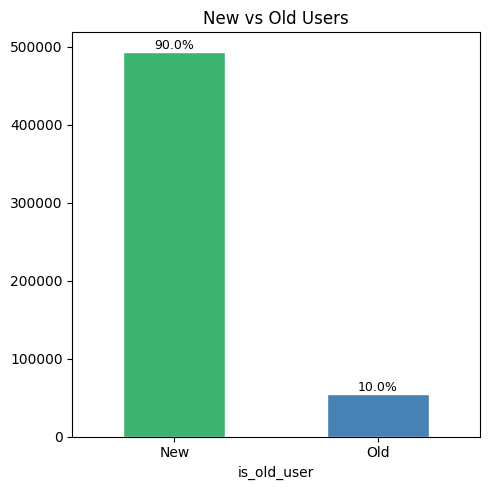

In [80]:
# ── New vs Old users ──
old_counts = df['is_old_user'].value_counts().rename({True: 'Old', False: 'New'})

fig, ax = plt.subplots(figsize=(5, 5))
old_counts.plot(kind='bar', ax=ax, color=['mediumseagreen', 'steelblue'], edgecolor='white')
ax.set_title('New vs Old Users')
ax.tick_params(axis='x', rotation=0)
for bar, count in zip(ax.patches, old_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{count/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

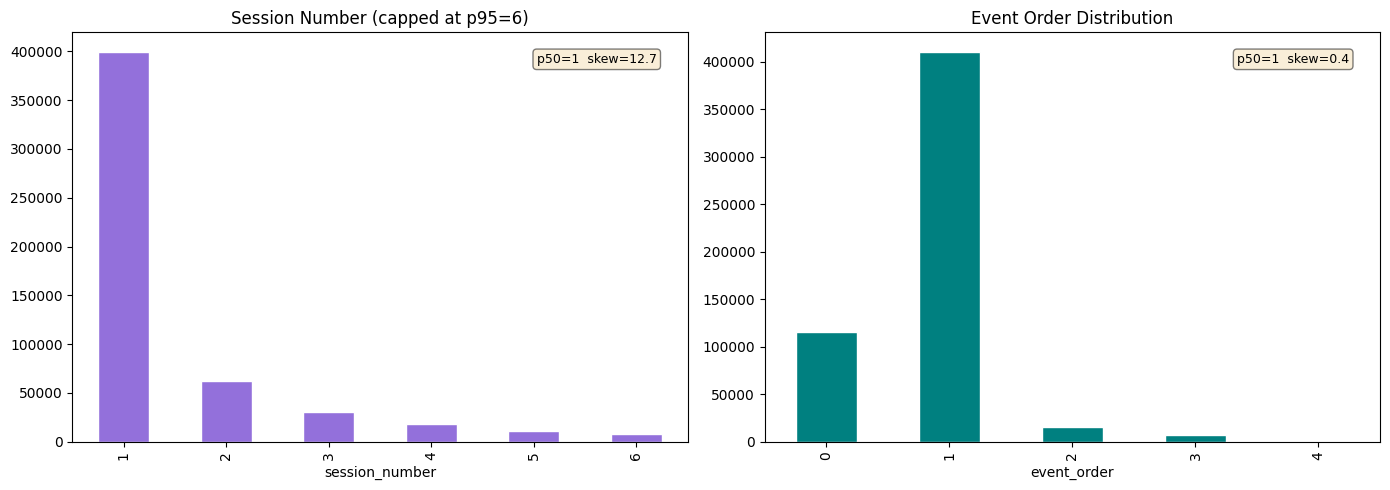

In [81]:
# ── Numeric distributions: session_number, event_order ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Session number (capped at 95th for visibility)
cap = int(df['session_number'].quantile(0.95))
sess_counts = df[df['session_number'] <= cap]['session_number'].value_counts().sort_index()
sess_counts.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title(f'Session Number (capped at p95={cap})')
axes[0].text(0.95, 0.95, f'p50={df["session_number"].median():.0f}  skew={df["session_number"].skew():.1f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Event order
eo_counts = df['event_order'].value_counts().sort_index()
eo_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Event Order Distribution')
axes[1].text(0.95, 0.95, f'p50={df["event_order"].median():.0f}  skew={df["event_order"].skew():.1f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

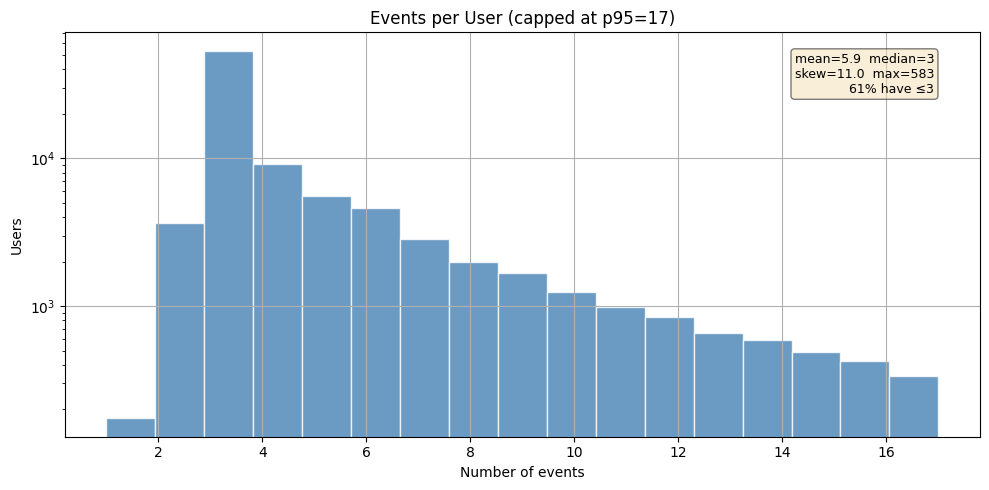

,count,mean,std,min,25%,50%,75%,max
events_per_user,93177.0,5.9,9.8,1.0,3.0,3.0,5.0,583.0


In [82]:
# ── Events per user — total activity volume ──
user_stats = df.groupby('user_id').agg(
    n_events=('event', 'count'),
    n_sessions=('session_id', 'nunique'),
    n_event_types=('event', 'nunique'),
).reset_index()

data = user_stats['n_events']
cap = int(data.quantile(0.95))

fig, ax = plt.subplots(figsize=(10, 5))
data[data <= cap].hist(bins=min(cap, 30), ax=ax, color='steelblue', edgecolor='white', alpha=0.8, log=True)
ax.set_title(f'Events per User (capped at p95={cap})')
ax.set_xlabel('Number of events')
ax.set_ylabel('Users')
ax.text(0.95, 0.95,
        f'mean={data.mean():.1f}  median={data.median():.0f}\n'
        f'skew={data.skew():.1f}  max={data.max()}\n'
        f'{(data<=3).mean()*100:.0f}% have ≤3',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

display(data.describe().to_frame('events_per_user').T.round(1))

### 2. Bivariate & Multivariate Analysis

Examine relationships between features. Structure: numeric×numeric, numeric×categorical, categorical×categorical, nonlinear dependence.

### Session-level aggregation (for bivariate analysis)

In [83]:
# ── Build session-level dataframe ──
all_events = sorted(df['event'].unique())
buy_events  = [e for e in all_events if any(k in e.lower() for k in ['buy', 'purchase', 'success'])]
cart_events = [e for e in all_events if any(k in e.lower() for k in ['cart', 'add'])]

sessions = df.groupby('session_id').agg(
    user_id        = ('user_id',            'first'),
    session_number = ('session_number',     'first'),
    device         = ('category',           'first'),
    source         = ('source',             'first'),
    country        = ('country',            'first'),
    is_old_user    = ('is_old_user',        'first'),
    start_time     = ('timestamp',          'min'),
    end_time       = ('timestamp',          'max'),
    n_events       = ('event',              'count'),
    n_pages        = ('page_location_cats', 'nunique'),
    pages_visited  = ('page_location_cats', lambda x: set(x)),
    event_sequence = ('event',              lambda x: ' → '.join(x)),
).reset_index()

sessions['duration_sec'] = (sessions['end_time'] - sessions['start_time']).dt.total_seconds()
sessions['did_basket']   = sessions['pages_visited'].apply(lambda p: 'basket.html' in p)
sessions['did_checkout'] = sessions['pages_visited'].apply(lambda p: 'yourinfo.html' in p)
sessions['did_buy']      = sessions['pages_visited'].apply(lambda p: 'registersuccess.html' in p)

if cart_events:
    cart_counts = df[df['event'].isin(cart_events)].groupby('session_id').size().rename('n_add_to_cart')
    sessions = sessions.merge(cart_counts, on='session_id', how='left')
    sessions['n_add_to_cart'] = sessions['n_add_to_cart'].fillna(0).astype(int)
    sessions['did_add_to_cart'] = sessions['n_add_to_cart'] > 0
else:
    sessions['n_add_to_cart']   = 0
    sessions['did_add_to_cart'] = sessions['did_basket']

print(f"Sessions: {sessions.shape}")
print(f"  basket: {sessions['did_basket'].sum():,} ({sessions['did_basket'].mean()*100:.1f}%)"
      f"  checkout: {sessions['did_checkout'].sum():,} ({sessions['did_checkout'].mean()*100:.1f}%)"
      f"  buy: {sessions['did_buy'].sum():,} ({sessions['did_buy'].mean()*100:.1f}%)")

Sessions: (116092, 19)
  basket: 6,894 (5.9%)  checkout: 2,130 (1.8%)  buy: 1,717 (1.5%)


In [84]:
# ── User-level aggregation ──
users = sessions.groupby('user_id').agg(
    total_events      = ('n_events',       'sum'),
    total_sessions    = ('session_id',     'count'),
    total_pages       = ('n_pages',        'sum'),
    total_duration    = ('duration_sec',   'sum'),
    avg_events_per_session = ('n_events',  'mean'),
    max_session_events     = ('n_events',  'max'),
    total_add_to_cart = ('n_add_to_cart',  'sum'),
    ever_bought       = ('did_buy',        'any'),
    ever_carted       = ('did_basket',     'any'),
    ever_checkout     = ('did_checkout',   'any'),
    is_old_user       = ('is_old_user',    'first'),
    device            = ('device',         'first'),
    source            = ('source',         'first'),
    country           = ('country',        'first'),
    max_session_number = ('session_number','max'),
).reset_index()

users['ever_bought']   = users['ever_bought'].astype(bool)
users['ever_carted']   = users['ever_carted'].astype(bool)
users['ever_checkout'] = users['ever_checkout'].astype(bool)

print(f"Users: {len(users):,}")
print(f"  ever bought:    {users['ever_bought'].sum():,} ({users['ever_bought'].mean()*100:.1f}%)")
print(f"  ever carted:    {users['ever_carted'].sum():,} ({users['ever_carted'].mean()*100:.1f}%)")
print(f"  ever checkout:  {users['ever_checkout'].sum():,} ({users['ever_checkout'].mean()*100:.1f}%)")
display(users.describe().round(1))

Users: 93,177
  ever bought:    1,702 (1.8%)
  ever carted:    5,637 (6.0%)
  ever checkout:  1,848 (2.0%)


,user_id,total_events,total_sessions,total_pages,total_duration,avg_events_per_session,max_session_events,total_add_to_cart,max_session_number
count,9.317700e+04,93177.0,93177.0,93177.0,93177.0,93177.0,93177.0,93177.0,93177.0
mean,2.427714e+08,5.9,1.2,1.9,279.0,4.4,5.0,0.2,1.4
std,1.122334e+09,9.8,0.8,2.4,10409.7,4.9,6.8,1.4,1.7
min,1.000300e+06,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
25%,5.950040e+06,3.0,1.0,1.0,4.9,3.0,3.0,0.0,1.0
50%,2.235949e+07,3.0,1.0,1.0,5.0,3.0,3.0,0.0,1.0
75%,6.152415e+07,5.0,1.0,2.0,38.5,4.0,4.0,0.0,1.0
max,9.985207e+09,583.0,12.0,55.0,1488862.5,583.0,583.0,91.0,143.0


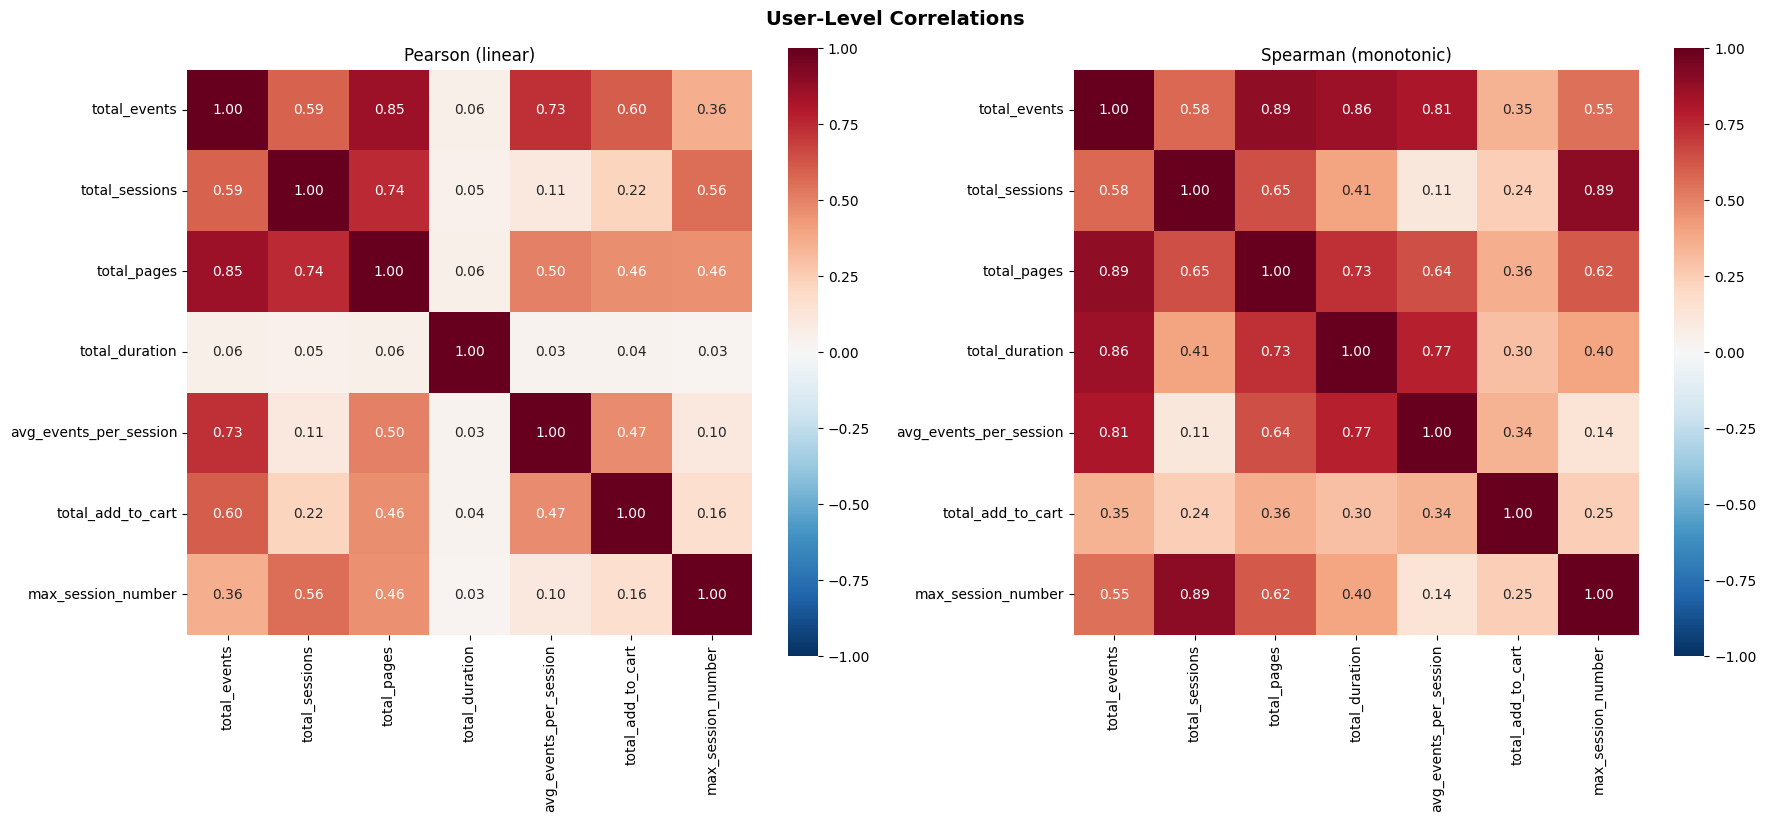

In [85]:
# ── Pearson vs Spearman correlation on user-level numerics ──
num_cols = ['total_events', 'total_sessions', 'total_pages', 'total_duration',
            'avg_events_per_session', 'total_add_to_cart', 'max_session_number']
pearson  = users[num_cols].corr(method='pearson')
spearman = users[num_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(pearson, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0], vmin=-1, vmax=1, square=True)
axes[0].set_title('Pearson (linear)')
sns.heatmap(spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1], vmin=-1, vmax=1, square=True)
axes[1].set_title('Spearman (monotonic)')
plt.suptitle('User-Level Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

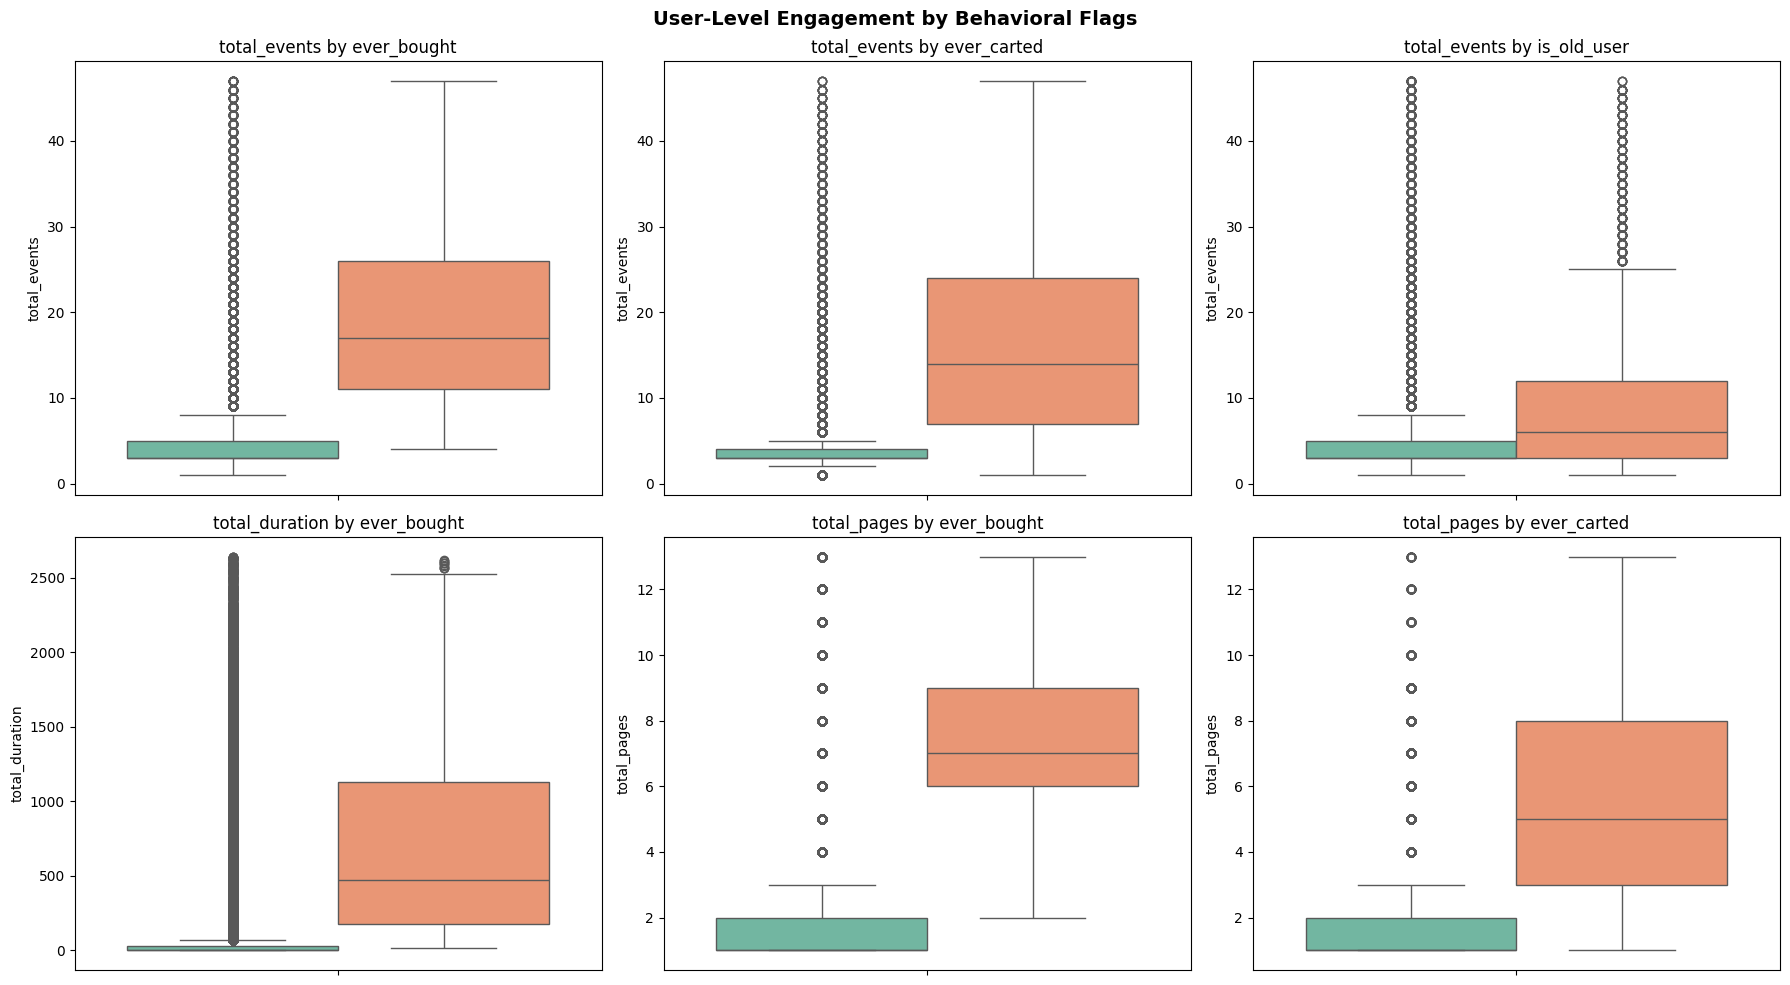

In [86]:
# ── Grouped boxplots: user-level engagement by behavioral flags ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

comparisons = [
    ('total_events',    'ever_bought',  axes[0, 0]),
    ('total_events',    'ever_carted',  axes[0, 1]),
    ('total_events',    'is_old_user',  axes[0, 2]),
    ('total_duration',  'ever_bought',  axes[1, 0]),
    ('total_pages',     'ever_bought',  axes[1, 1]),
    ('total_pages',     'ever_carted',  axes[1, 2]),
]

for num_col, cat_col, ax in comparisons:
    cap = users[num_col].quantile(0.99)
    data = users[users[num_col] <= cap]
    sns.boxplot(data=data, hue=cat_col, y=num_col, ax=ax, palette='Set2', legend=False)
    ax.set_title(f'{num_col} by {cat_col}')

plt.suptitle('User-Level Engagement by Behavioral Flags', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

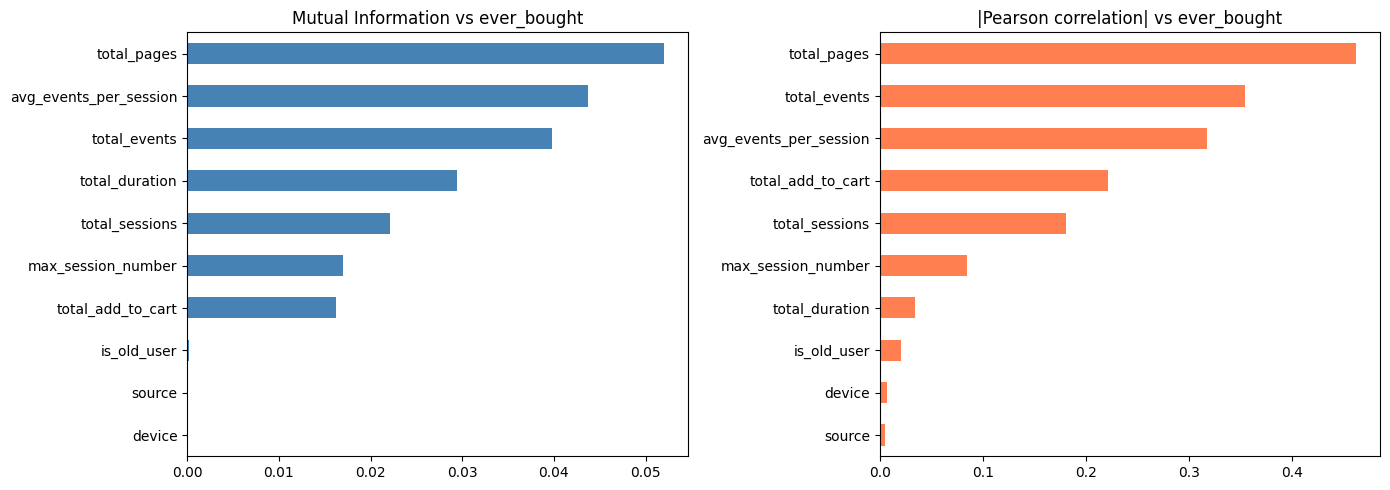

In [87]:
# ── Mutual Information: each feature vs ever_bought (user level) ──
mi_df = users[['total_events', 'total_sessions', 'total_pages', 'total_duration',
               'avg_events_per_session', 'total_add_to_cart', 'max_session_number',
               'device', 'source', 'is_old_user']].copy()

for col in ['device', 'source']:
    mi_df[col] = LabelEncoder().fit_transform(mi_df[col].astype(str))
mi_df['is_old_user'] = mi_df['is_old_user'].astype(int)

target = users['ever_bought'].astype(int)
mi_scores = mutual_info_classif(mi_df, target,
    discrete_features=[False]*7 + [True, True, True], random_state=42)
mi_result = pd.Series(mi_scores, index=mi_df.columns).sort_values(ascending=False)

pearson_vs_target = mi_df.corrwith(target).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mi_result.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Mutual Information vs ever_bought')
axes[0].invert_yaxis()
pearson_vs_target.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('|Pearson correlation| vs ever_bought')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

### 3. Business Analysis

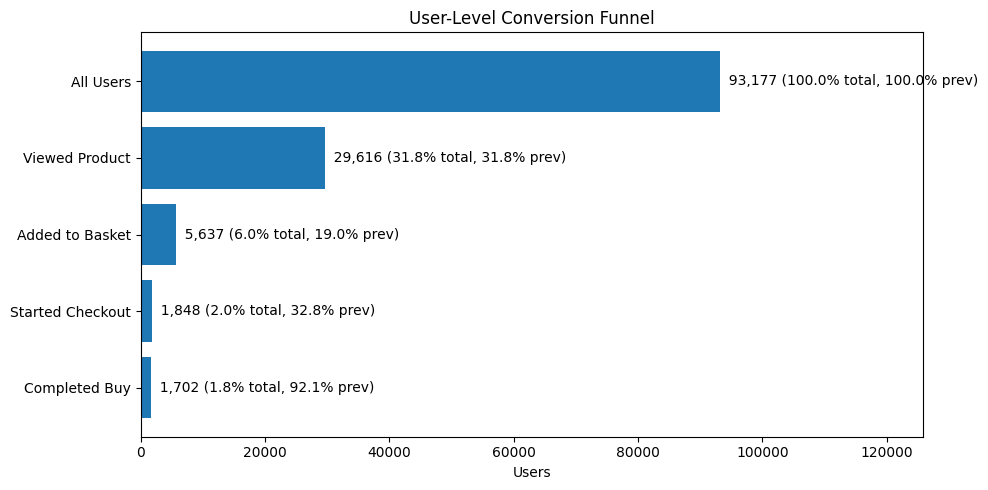

In [88]:
# User-level conversion funnel
funnel_stages = {
    "All Users": len(users),
    "Viewed Product": users["total_pages"].gt(1).sum(),
    "Added to Basket": users["ever_carted"].sum(),
    "Started Checkout": users["ever_checkout"].sum(),
    "Completed Buy": users["ever_bought"].sum(),
}

labels = list(funnel_stages.keys())
values = list(funnel_stages.values())

pct_total = [v / values[0] * 100 for v in values]
pct_prev = [100.0] + [
    values[i] / values[i - 1] * 100 if values[i - 1] > 0 else 0
    for i in range(1, len(values))
]

plot_labels = labels[::-1]
plot_values = values[::-1]
plot_pct_total = pct_total[::-1]
plot_pct_prev = pct_prev[::-1]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(plot_labels, plot_values)

for bar, value, pct_t, pct_p in zip(
    bars,
    plot_values,
    plot_pct_total,
    plot_pct_prev,
):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"  {value:,} ({pct_t:.1f}% total, {pct_p:.1f}% prev)",
        va="center",
    )

ax.set_title("User-Level Conversion Funnel")
ax.set_xlabel("Users")
ax.set_xlim(0, max(values) * 1.35)

plt.tight_layout()
plt.show()

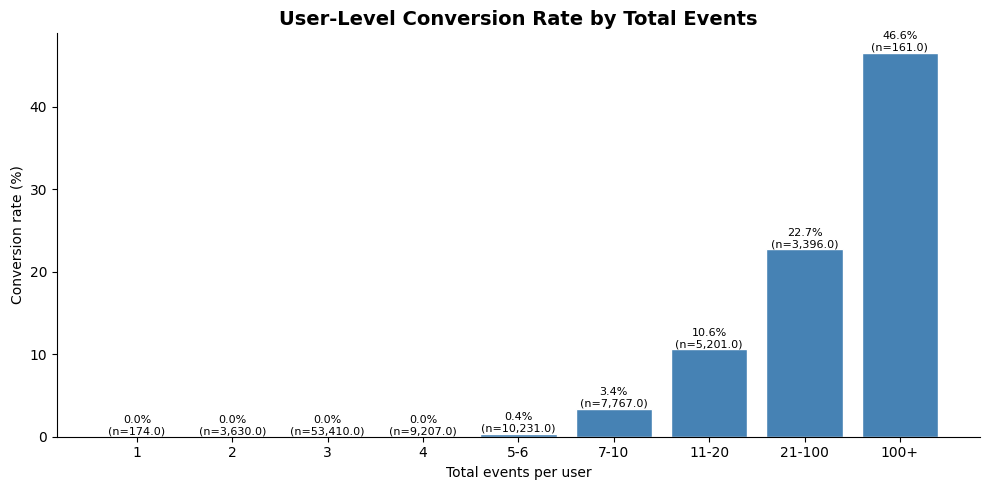

In [89]:
# ── User-level activation threshold ──
users['event_bin'] = pd.cut(users['total_events'],
    bins=[0, 1, 2, 3, 4, 6, 10, 20, 100, float('inf')],
    labels=['1', '2', '3', '4', '5-6', '7-10', '11-20', '21-100', '100+'])

conv_by_events = users.groupby('event_bin')['ever_bought'].agg(['sum', 'count', 'mean'])
conv_by_events.columns = ['buyers', 'users', 'conv_rate']
conv_by_events['conv_rate_pct'] = conv_by_events['conv_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(conv_by_events.index.astype(str), conv_by_events['conv_rate_pct'],
              color='steelblue', edgecolor='white')
for bar, (_, row) in zip(bars, conv_by_events.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{row['conv_rate_pct']:.1f}%\n(n={row['users']:,})", ha='center', va='bottom', fontsize=8)
ax.set_title('User-Level Conversion Rate by Total Events', fontsize=14, fontweight='bold')
ax.set_xlabel('Total events per user')
ax.set_ylabel('Conversion rate (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

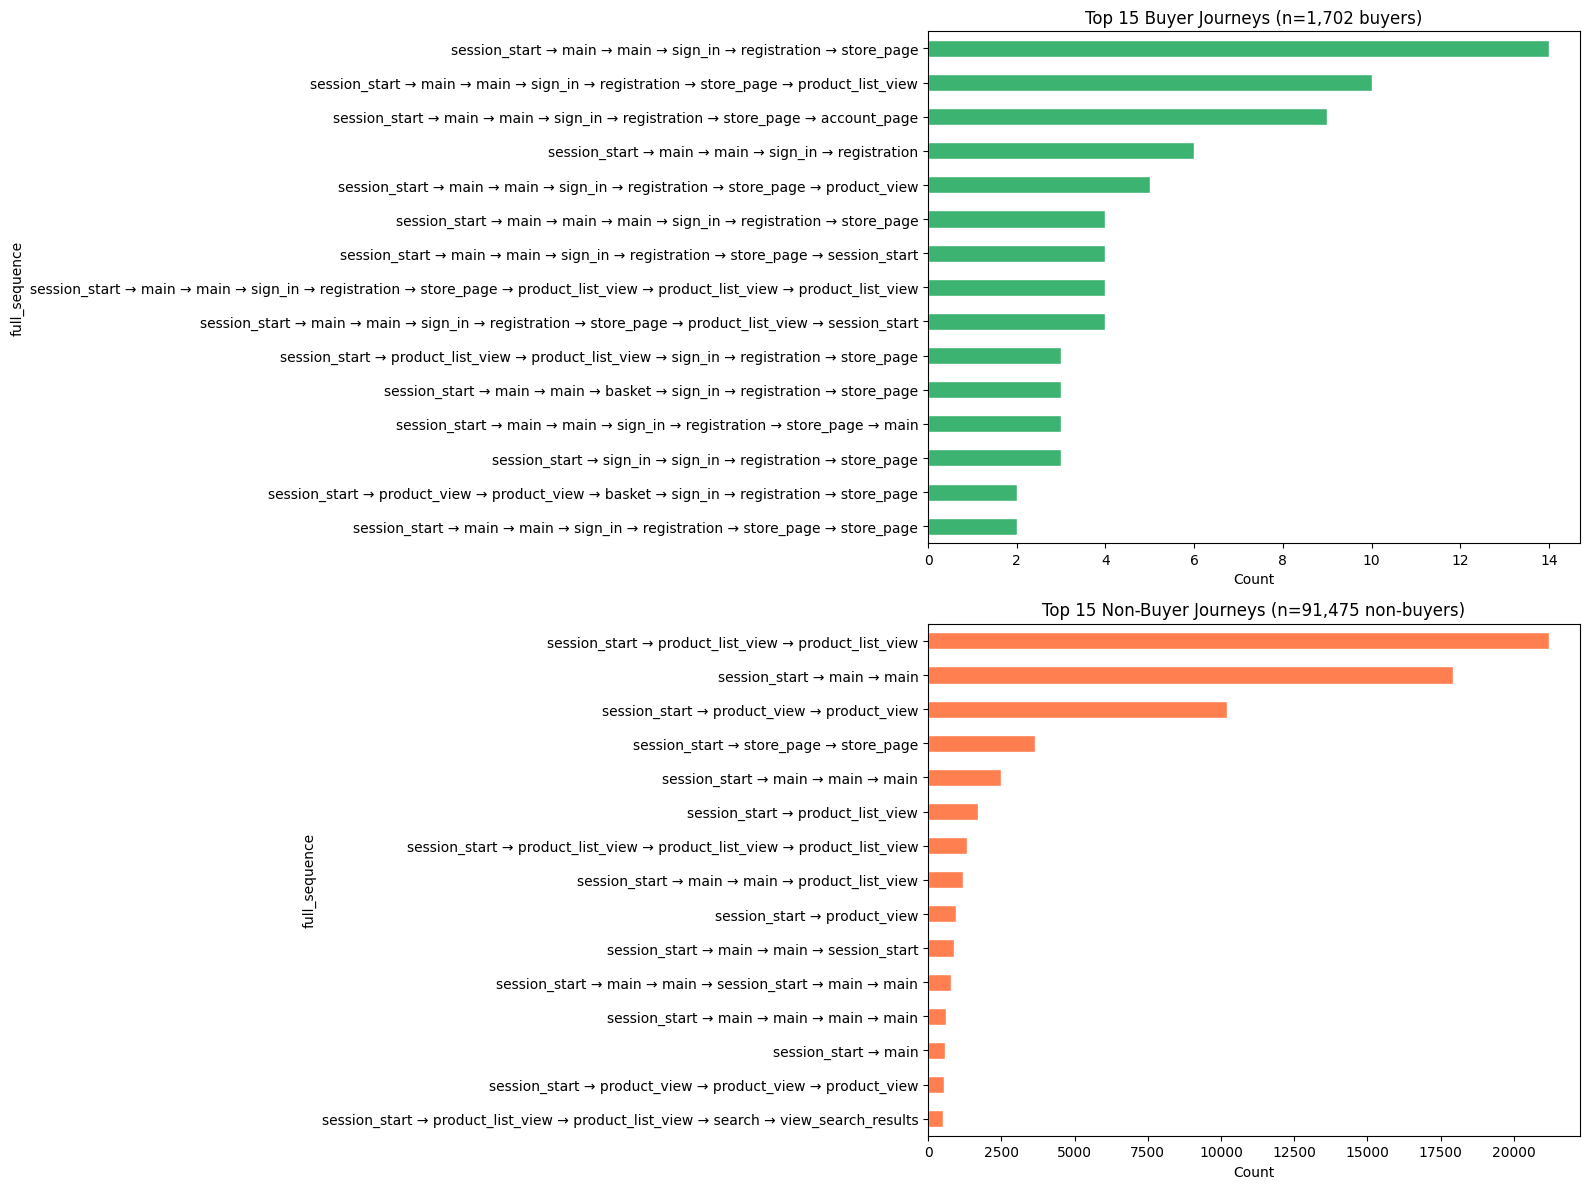

In [90]:
# ── Top event sequences: buyers vs non-buyers (user-level, full journey) ──
user_sequences = (df.sort_values(['user_id', 'timestamp'])
                  .groupby('user_id')['event']
                  .apply(lambda x: ' → '.join(x))
                  .reset_index()
                  .rename(columns={'event': 'full_sequence'}))

user_sequences = user_sequences.merge(users[['user_id', 'ever_bought']], on='user_id')

buyer_seqs = user_sequences[user_sequences['ever_bought']]['full_sequence'].value_counts().head(15)
non_buyer_seqs = user_sequences[~user_sequences['ever_bought']]['full_sequence'].value_counts().head(15)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

buyer_seqs.plot(kind='barh', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title(f'Top 15 Buyer Journeys (n={user_sequences["ever_bought"].sum():,} buyers)')
axes[0].invert_yaxis()
axes[0].set_xlabel('Count')

non_buyer_seqs.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title(f'Top 15 Non-Buyer Journeys (n={(~user_sequences["ever_bought"]).sum():,} non-buyers)')
axes[1].invert_yaxis()
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

### 4. URL-Based Feature Exploration

The `page_location` column contains full URLs that encode product catalog structure. This section explores the URL hierarchy to identify features for segmentation: departments, subcategories, brands, and audience/demographic signals.

The URL structure follows a consistent pattern:
```
/google+redesign/{L1_department}/{L2_subcategory_or_product}/{L3_detail}/...
```

Non-catalog URLs are system pages (`basket.html`, `signin.html`, etc.) and the homepage (`/`).

In [91]:
# ── Parse catalog URLs ──
df['url_path'] = df['page_location'].apply(
    lambda u: urlparse(str(u)).path.strip('/').replace('+', ' ')
)
df['is_catalog'] = df['url_path'].apply(
    lambda p: p.split('/')[0].startswith('google') and len(p.split('/')) >= 2
)

catalog = df[df['is_catalog']].copy()
catalog['parts'] = catalog['url_path'].apply(lambda p: p.split('/'))
catalog['depth'] = catalog['parts'].apply(len)
catalog['L1']    = catalog['parts'].apply(lambda p: p[1])
catalog['L2']    = catalog['parts'].apply(lambda p: p[2] if len(p) >= 3 else None)

print(f"Total events:           {len(df):,}")
print(f"Events on catalog URLs: {len(catalog):,}  ({len(catalog)/len(df)*100:.1f}%)")
print(f"Unique L1 values:       {catalog['L1'].nunique()}")
print(f"Unique L2 values:       {catalog['L2'].dropna().nunique()}")

Total events:           549,020
Events on catalog URLs: 284,443  (51.8%)
Unique L1 values:       58
Unique L2 values:       609


In [92]:
# ── Which event types carry catalog URL information? ──
event_catalog = pd.crosstab(df['event'], df['is_catalog'], normalize='index')
event_catalog.columns = ['non_catalog', 'catalog']
event_catalog['total_events'] = df['event'].value_counts()
event_catalog = event_catalog.sort_values('catalog', ascending=False)

print("Fraction of each event type on catalog URLs:\n")
display(event_catalog.style.format({'catalog': '{:.1%}', 'non_catalog': '{:.1%}', 'total_events': '{:,}'}))

Fraction of each event type on catalog URLs:



,non_catalog,catalog,total_events
event,,,
view_item_list,0.0%,100.0%,9
product_view,0.2%,99.8%,"77,665"
product_list_view,3.1%,96.9%,"142,171"
add_to_cart,15.0%,85.0%,"15,180"
session_start,51.5%,48.5%,"115,953"
account_page,100.0%,0.0%,"3,896"
search,100.0%,0.0%,"8,154"
view_search_results,100.0%,0.0%,"7,581"
store_page,100.0%,0.0%,"23,626"


In [93]:
# ── User coverage: who has catalog URL data? ──
info_events = df[df['is_catalog'] & df['event'].isin(['product_list_view', 'product_view', 'add_to_cart'])]

total_users   = df['user_id'].nunique()
users_w_info  = info_events['user_id'].nunique()

engaged_ids   = set(df.groupby('user_id').size().pipe(lambda s: s[s >= 5].index))
engaged_w_info = info_events[info_events['user_id'].isin(engaged_ids)]['user_id'].nunique()

print(f"Total users:                        {total_users:,}")
print(f"Users with >=1 category event:       {users_w_info:,}  ({users_w_info/total_users*100:.1f}%)")
print(f"Engaged users (>=5 events):          {len(engaged_ids):,}")
print(f"Engaged users with category data:   {engaged_w_info:,}  ({engaged_w_info/len(engaged_ids)*100:.1f}%)")

Total users:                        93,177
Users with >=1 category event:       60,758  (65.2%)
Engaged users (>=5 events):          26,756
Engaged users with category data:   22,094  (82.6%)


In [94]:
# ── Section extraction with L1 remapping ──
# L1 → canonical department
L1_TO_DEPT = {
    'apparel': 'apparel',
    'lifestyle': 'lifestyle',
    'stationery': 'stationery',
    # Subcategories promoted to L1 in the flat 2021 scheme → remap
    'accessories': 'apparel',
    'bags': 'lifestyle',
    'drinkware': 'lifestyle',
    'office': 'lifestyle',
    'electronics': 'lifestyle',
}

SPECIAL_SECTIONS = {'clearance', 'new', 'eco friendly', 'campus collection', 'shop by brand'}

def classify_section(l1):
    if l1 in L1_TO_DEPT:
        return ('department', L1_TO_DEPT[l1])
    if l1 in SPECIAL_SECTIONS:
        return ('special', l1)
    return ('unknown', l1)

catalog['section_type'], catalog['department'] = zip(*catalog['L1'].map(classify_section))

# ── Department distribution (after remapping) ──
dept_events = catalog[catalog['section_type'] == 'department']
dept_counts = dept_events['department'].value_counts()
dept_pct = (dept_counts / len(dept_events) * 100).round(1)

print("Department distribution (after L1 remapping):\n")
dept_summary = pd.DataFrame({
    'events': dept_counts,
    'pct': dept_pct,
    'users': [dept_events[dept_events['department'] == d]['user_id'].nunique() for d in dept_counts.index],
    'L1_values_mapped': [
        ', '.join(sorted(k for k, v in L1_TO_DEPT.items() if v == d))
        for d in dept_counts.index
    ]
})
display(dept_summary.style.format({'events': '{:,}', 'pct': '{:.1f}%', 'users': '{:,}'}))

# ── Special section flags ──
special_events = catalog[catalog['section_type'] == 'special']
spec_counts = special_events['L1'].value_counts()

print("\nSpecial section event counts:\n")
spec_summary = pd.DataFrame({
    'events': spec_counts,
    'users': [special_events[special_events['L1'] == s]['user_id'].nunique() for s in spec_counts.index]
})
display(spec_summary.style.format({'events': '{:,}', 'users': '{:,}'}))

# ── Coverage: unknown L1 values ──
unk = catalog[catalog['section_type'] == 'unknown']

Department distribution (after L1 remapping):



,events,pct,users,L1_values_mapped
department,,,,
apparel,"151,910",71.9%,"42,302","accessories, apparel"
lifestyle,"46,446",22.0%,"12,903","bags, drinkware, electronics, lifestyle, office"
stationery,"12,937",6.1%,"5,110",stationery



Special section event counts:



,events,users
L1,,
shop by brand,"36,111","12,056"
clearance,"12,692","5,641"
new,"9,294","5,031"
campus collection,"6,185","4,032"
eco friendly,"5,484","3,457"


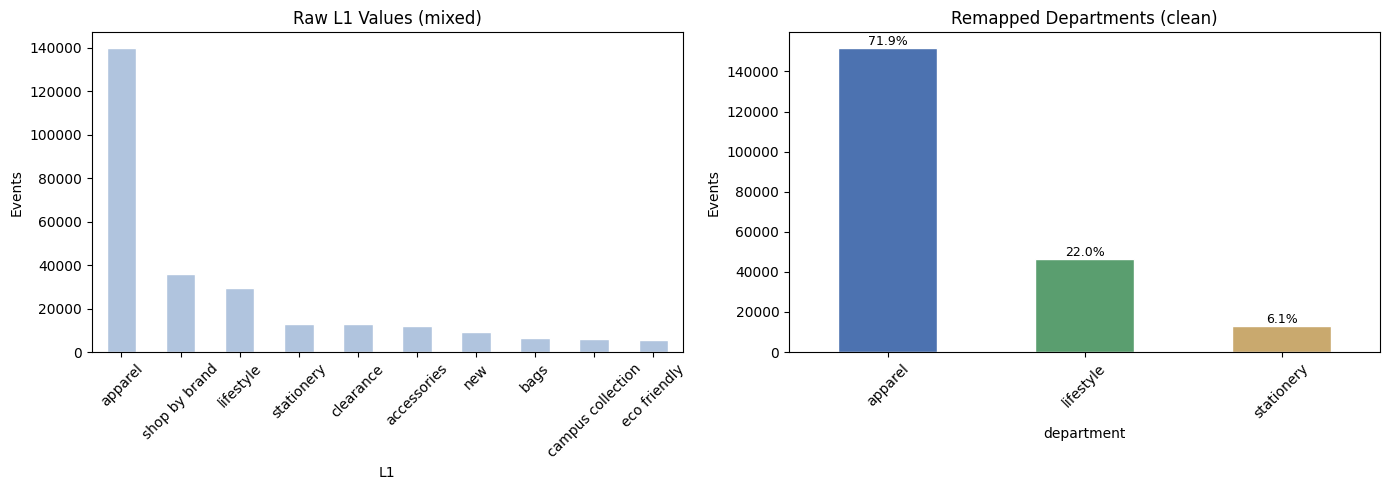

In [95]:
# ── Visualization: departments after remapping vs raw L1 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw L1 top values
raw_top = catalog['L1'].value_counts().head(10)
raw_top.plot(kind='bar', ax=axes[0], color='lightsteelblue', edgecolor='white')
axes[0].set_title('Raw L1 Values (mixed)')
axes[0].set_ylabel('Events')
axes[0].tick_params(axis='x', rotation=45)

# Right: remapped departments
dept_colors_map = {'apparel': '#4C72B0', 'lifestyle': '#5A9E6F', 'stationery': '#C9A96E'}
dept_counts.plot(kind='bar', ax=axes[1],
                 color=[dept_colors_map.get(d, '#999') for d in dept_counts.index],
                 edgecolor='white')
axes[1].set_title('Remapped Departments (clean)')
axes[1].set_ylabel('Events')
axes[1].tick_params(axis='x', rotation=45)
for bar, pct in zip(axes[1].patches, dept_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [96]:
# ── Subcategory keyword search on URL body ──

# Canonical subcategory → (regex pattern, parent department, is_demographic)
SUBCATEGORY_RULES = {
    # Apparel subcategories
    'mens':        (r'\bmens\b|\bmen s\b|\bmen\'s\b',       'apparel',    True),
    'womens':      (r'\bwomens\b|\bwomen s\b|\bwomen\'s\b|\bwomen\b|\bladies\b', 'apparel', True),
    'kids':        (r'\bkids\b|\byouth\b|\btoddler\b|\binfant\b', 'apparel', True),
    'unisex':      (r'\bunisex\b',                              'apparel',    True),
    'hats':        (r'\bhats\b|\bheadgear\b',                 'apparel',    False),
    'accessories': (r'\baccessories\b',                         'apparel',    False),
    'socks':       (r'\bsocks\b',                               'apparel',    False),
    # Lifestyle subcategories
    'bags':        (r'\bbags\b|\bmore bags\b|\bshopping and totes\b', 'lifestyle', False),
    'drinkware':   (r'\bdrinkware\b|\bmugs tumblers\b|\bmugs and cups\b|\bwater bottles\b', 'lifestyle', False),
    'small goods': (r'\bsmall goods\b',                         'lifestyle',  False),
    'office':      (r'\boffice\b',                              'lifestyle',  False),
    'fun and games': (r'\bfun and games\b|\bfun\b',           'lifestyle',  False),
    'electronics': (r'\belectronics\b',                         'lifestyle',  False),
    # Stationery subcategories
    'notebooks':   (r'\bnotebooks\b|\bnotebooks journals\b',  'stationery', False),
    'stickers':    (r'\bstickers\b',                            'stationery', False),
    'writing':     (r'\bwriting instruments\b|\bwriting\b',   'stationery', False),
}

# Build URL body: everything after 'google redesign/', space-joined
catalog['url_body'] = catalog['parts'].apply(lambda p: ' '.join(p[1:]).lower() if len(p) > 1 else '')

# Match each subcategory
subcat_records = []
for subcat, (pattern, parent, is_demo) in SUBCATEGORY_RULES.items():
    mask = catalog['url_body'].str.contains(pattern, regex=True, na=False)
    hits = catalog[mask]
    subcat_records.append({
        'subcategory': subcat,
        'parent_dept': parent,
        'demographic': is_demo,
        'events': len(hits),
        'users': hits['user_id'].nunique(),
        'pct_of_catalog': len(hits) / len(catalog) * 100,
    })

subcat_df = pd.DataFrame(subcat_records).sort_values('events', ascending=False)
subcat_df['cum_pct'] = subcat_df['pct_of_catalog'].cumsum().round(1)

print("Subcategory ranking (keyword search on full URL body):\n")
display(subcat_df.style.format({
    'events': '{:,}', 'users': '{:,}',
    'pct_of_catalog': '{:.1f}%', 'cum_pct': '{:.1f}%'
}))

Subcategory ranking (keyword search on full URL body):



,subcategory,parent_dept,demographic,events,users,pct_of_catalog,cum_pct
0,mens,apparel,True,"25,668","8,525",9.0%,9.0%
8,drinkware,lifestyle,False,"15,677","5,459",5.5%,14.5%
7,bags,lifestyle,False,"15,298","5,407",5.4%,19.9%
5,accessories,apparel,False,"12,115","4,425",4.3%,24.2%
1,womens,apparel,True,"6,756","2,550",2.4%,26.5%
2,kids,apparel,True,"4,947","2,131",1.7%,28.3%
10,office,lifestyle,False,"4,850","1,815",1.7%,30.0%
4,hats,apparel,False,"4,831","2,559",1.7%,31.7%
9,small goods,lifestyle,False,"4,557","2,255",1.6%,33.3%
14,stickers,stationery,False,"4,429","1,935",1.6%,34.8%


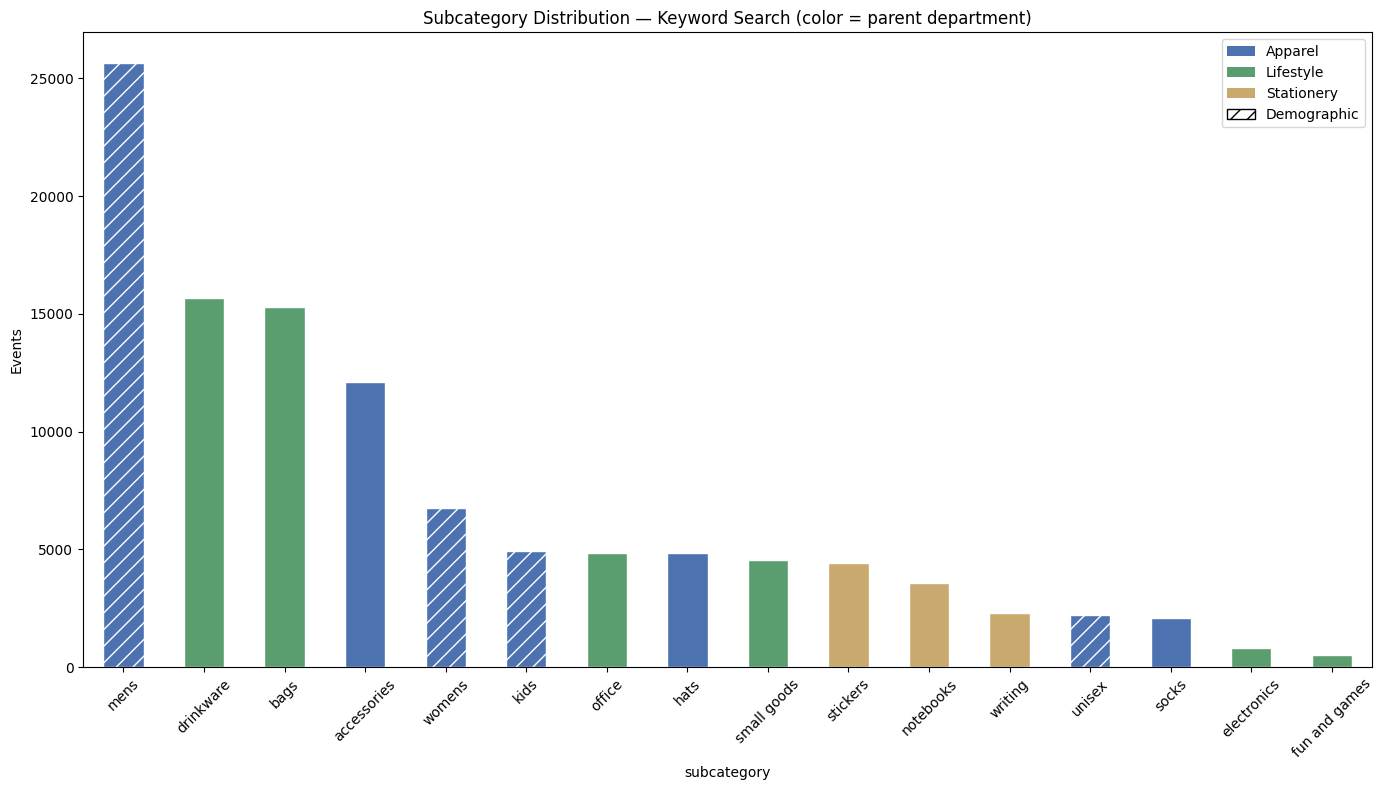

In [97]:
# ── Visualization: subcategories by parent department ──
fig, ax = plt.subplots(figsize=(14, 8))

dept_colors_sub = {'apparel': '#4C72B0', 'lifestyle': '#5A9E6F', 'stationery': '#C9A96E'}
colors = [dept_colors_sub[r['parent_dept']] for _, r in subcat_df.iterrows()]

subcat_df.plot(kind='bar', x='subcategory', y='events', ax=ax,
               color=colors, edgecolor='white', legend=False)
ax.set_title('Subcategory Distribution — Keyword Search (color = parent department)')
ax.set_ylabel('Events')
ax.tick_params(axis='x', rotation=45)

# Add demographic markers
for i, (_, row) in enumerate(subcat_df.iterrows()):
    if row['demographic']:
        ax.patches[i].set_hatch('//')

# Legend


handles = [Patch(facecolor=c, label=d.title()) for d, c in dept_colors_sub.items()]
handles.append(Patch(facecolor='white', edgecolor='black', hatch='//', label='Demographic'))
ax.legend(handles=handles, loc='upper right')
plt.tight_layout()
plt.show()

# ── Demographic summary ──
demo_df = subcat_df[subcat_df['demographic']].copy()
demo_users = set()
for subcat in demo_df['subcategory']:
    pattern = SUBCATEGORY_RULES[subcat][0]
    mask = catalog['url_body'].str.contains(pattern, regex=True, na=False)
    demo_users |= set(catalog[mask]['user_id'])

In [98]:
# ── Brand keyword search ──

# Build L2+ body: everything after L1 (skip department/section name)
catalog['url_l2plus'] = catalog['parts'].apply(
    lambda p: ' '.join(p[2:]).lower() if len(p) > 2 else ''
)

brand_records = []

# YouTube and Android: straightforward keyword match on full url_body
for brand, pattern in [('youtube', r'\byoutube\b'), ('android', r'\bandroid\b')]:
    mask = catalog['url_body'].str.contains(pattern, regex=True, na=False)
    hits = catalog[mask]
    brand_records.append({
        'brand': brand,
        'events': len(hits),
        'users': hits['user_id'].nunique(),
    })

# Google: match in L2+ body only (avoids 'google redesign' prefix),
# OR under the explicit /shop by brand/ path
google_l2_mask = catalog['url_l2plus'].str.contains(r'\bgoogle\b', regex=True, na=False)
google_brand_path = (catalog['L1'] == 'shop by brand') & catalog['url_body'].str.contains(r'\bgoogle\b', na=False)
google_mask = google_l2_mask | google_brand_path
google_hits = catalog[google_mask]
brand_records.append({
    'brand': 'google',
    'events': len(google_hits),
    'users': google_hits['user_id'].nunique(),
})

brand_result = pd.DataFrame(brand_records).sort_values('events', ascending=False)
brand_result['pct'] = (brand_result['events'] / brand_result['events'].sum() * 100).round(1)

print("Brand ranking (keyword search, google matched in L2+ only):\n")
display(brand_result.style.format({'events': '{:,}', 'users': '{:,}', 'pct': '{:.1f}%'}))

Brand ranking (keyword search, google matched in L2+ only):



,brand,events,users,pct
2,google,"64,102","18,999",65.1%
0,youtube,"29,380","9,366",29.8%
1,android,"4,971","2,091",5.0%


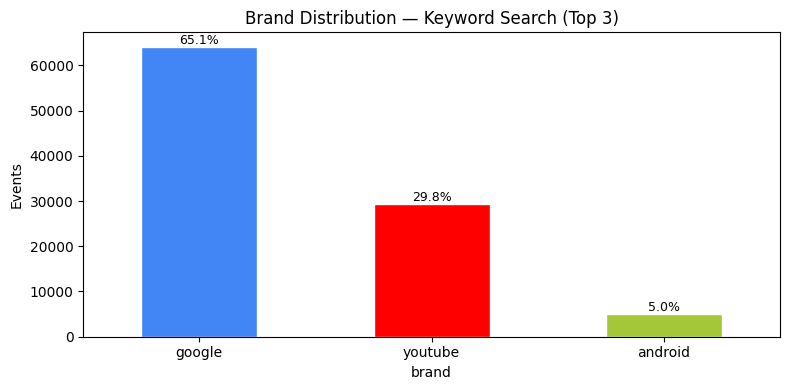

Users with any brand signal: 28,129 (30.2% of all users)


In [99]:
# ── Visualization: brand distribution ──
fig, ax = plt.subplots(figsize=(8, 4))
brand_colors = {'youtube': '#FF0000', 'google': '#4285F4', 'android': '#A4C639'}
colors = [brand_colors.get(b, '#999') for b in brand_result['brand']]

brand_result.plot(kind='bar', x='brand', y='events', ax=ax,
                  color=colors, edgecolor='white', legend=False)
ax.set_title('Brand Distribution — Keyword Search (Top 3)')
ax.set_ylabel('Events')
ax.tick_params(axis='x', rotation=0)
for bar, pct in zip(ax.patches, brand_result['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# ── Brand coverage ──
all_brand_users = set()
for _, row in brand_result.iterrows():
    brand = row['brand']
    if brand == 'google':
        mask = google_mask
    elif brand == 'youtube':
        mask = catalog['url_body'].str.contains(r'\byoutube\b', regex=True, na=False)
    else:
        mask = catalog['url_body'].str.contains(r'\bandroid\b', regex=True, na=False)
    all_brand_users |= set(catalog[mask]['user_id'])

print(f"Users with any brand signal: {len(all_brand_users):,} "
      f"({len(all_brand_users)/total_users*100:.1f}% of all users)")